<div align='center'>

# **Práctica 2 — Minería de Textos y Análisis de Temas**

**Máster Universitario en Inteligencia Artificial**  
**Asignatura:** Minería de Textos y Modelos de Lenguaje

<br/>
Autores:
- Cristian Rubio Barato — <a href='mailto:Cristian.Rubio@alu.uclm.es'>Cristian.Rubio@alu.uclm.es</a>  
- José Lara Navarro — <a href='mailto:Jose.Lara3@alu.uclm.es'>Jose.Lara3@alu.uclm.es</a>

</div>

<a id='indice'></a>

**Índice**

- [1. Carga, preprocesado y limpieza del conjunto de datos](#sec1)
- [2. Vectorización del corpus](#sec2)
- [3. Modelado y selección del número óptimo de temas](#sec3)
- [4. Declaración de uso responsable de Inteligencia Artificial](#sec4)

<a id='sec1'></a>
## 1. Carga, preprocesado y limpieza del conjunto de datos

Cargamos el dataset, extraemos la columna `cuerpo` como corpus y aplicamos el pipeline canónico:

1. **Limpieza básica**: minúsculas, eliminación de URLs, caracteres no alfabéticos y normalización de espacios.
2. **Lematización con spaCy**: procesamiento por lotes con barra de progreso, filtrando stopwords, puntuación, espacios y tokens de longitud 1. Se usa `n_process=1` para evitar el error de memoria que produce el multiprocesamiento en Windows con modelos grandes.

El resultado se guarda en `corpus_lemas.pkl` para no repetir la lematización en ejecuciones posteriores.

In [2]:
import pandas as pd
import re
import pickle
import os
import spacy
from tqdm import tqdm

df = pd.read_csv("data_larazon_publico_v2.csv")
print(f"Dimensiones del dataset: {df.shape}")

corpus = df["cuerpo"].dropna().reset_index(drop=True)
print(f"Documentos en el corpus (tras eliminar NaN): {len(corpus)}")
print(f"\nEjemplo (primeros 200 caracteres):\n  {corpus.iloc[0][:200]}.")


def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r"http\S+|www\S+", "", texto)
    texto = re.sub(r"[^a-záéíóúüñ\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


corpus_limpio = corpus.apply(limpiar_texto)
print("\nEjemplo original vs. limpio:")
print(f"  Original : {corpus.iloc[0][:100]}")
print(f"  Limpio   : {corpus_limpio.iloc[0][:100]}")

PICKLE_PATH = "corpus_lemas.pkl"


def lematizar_corpus(corpus_serie, batch_size=128):
    nlp = spacy.load("es_core_news_sm", disable=["parser", "ner"])
    textos = corpus_serie.tolist()
    salida = []
    for doc in tqdm(
        nlp.pipe(textos, batch_size=batch_size, n_process=1),
        total=len(textos),
        desc="Lematizando",
    ):
        tokens = [
            t.lemma_
            for t in doc
            if not t.is_stop
            and not t.is_punct
            and not t.is_space
            and t.is_alpha
            and len(t.lemma_) > 1
        ]
        salida.append(" ".join(tokens))
    return pd.Series(salida, index=corpus_serie.index)


if os.path.exists(PICKLE_PATH):
    print(f"\nCargando corpus lematizado desde '{PICKLE_PATH}'.")
    with open(PICKLE_PATH, "rb") as f:
        lemas = pickle.load(f)
    print("Corpus cargado correctamente.")
else:
    print("\nIniciando lematización.")
    lemas = lematizar_corpus(corpus_limpio)
    with open(PICKLE_PATH, "wb") as f:
        pickle.dump(lemas, f)
    print(f"Corpus guardado en '{PICKLE_PATH}'.")

print("\nEjemplos de texto limpio vs. lematizado:\n")
for i in [0, 1, 2]:
    print(f"  Limpio     : {corpus_limpio.iloc[i][:100]}")
    print(f"  Lematizado : {lemas.iloc[i][:100]}")
    print()

print("Corpus lematizado (Serie de pandas):")
lemas

Dimensiones del dataset: (58424, 4)
Documentos en el corpus (tras eliminar NaN): 58424

Ejemplo (primeros 200 caracteres):
  dos semanas después de su puesta de largo y presentación en sociedad, el primer submarino s-80 para la armada, el s-81 "isaac peral", ha entrado hoy en el agua tras una delicada y larga maniobra que s.

Ejemplo original vs. limpio:
  Original : dos semanas después de su puesta de largo y presentación en sociedad, el primer submarino s-80 para 
  Limpio   : dos semanas después de su puesta de largo y presentación en sociedad el primer submarino s para la a

Cargando corpus lematizado desde 'corpus_lemas.pkl'.
Corpus cargado correctamente.

Ejemplos de texto limpio vs. lematizado:

  Limpio     : dos semanas después de su puesta de largo y presentación en sociedad el primer submarino s para la a
  Lematizado : semana puesta presentación sociedad submarino armada isaac peral entrar agua delicado largo maniobra

  Limpio     : este viernes el presidente del gobierno 

0        semana puesta presentación sociedad submarino ...
1        viernes presidente gobierno pedro sánchez vice...
2        ministro interior fernando marlaska alcalde gu...
3        duro familia olivia anna gimeno zimmerman cump...
4        quedar preso eta recibir beneficio traslado pa...
                               ...                        
58419    comisión europea iniciar procedimiento infracc...
58420    pleno asamblea madrid aprobar jueves proyecto ...
58421    comisión investigación parlamentario accidente...
58422    erc pdecat calificar jueves inaceptable grabac...
58423    junta portavoz congreso acordar oposición pp a...
Length: 58424, dtype: str

<a id='sec2'></a>
## 2. Vectorización del corpus

Transformamos el corpus lematizado en una representación numérica mediante **Bag of Words (BoW)** con `CountVectorizer` de scikit-learn.

Con ~58.000 documentos, `min_df` absoluto tiene mucho más margen que en la P1: un valor de 20 ya filtra términos presentes en menos del 0.03% del corpus. Exploramos varias configuraciones antes de fijar la definitiva.

In [3]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

configuraciones = [
    {"ngram_range": (1, 1), "min_df": 5,     "max_df": 0.95, "max_features": None},
    {"ngram_range": (1, 1), "min_df": 10,    "max_df": 0.90, "max_features": None},
    {"ngram_range": (1, 2), "min_df": 10,    "max_df": 0.90, "max_features": None},
    {"ngram_range": (1, 2), "min_df": 20,    "max_df": 0.90, "max_features": None},
    {"ngram_range": (1, 2), "min_df": 20,    "max_df": 0.90, "max_features": 10000},
    {"ngram_range": (1, 2), "min_df": 50,    "max_df": 0.85, "max_features": 10000},
    {"ngram_range": (1, 2), "min_df": 100,   "max_df": 0.85, "max_features": 10000},
    {"ngram_range": (1, 2), "min_df": 0.005, "max_df": 0.80, "max_features": 10000},
]

print(
    f"{'Config':<8} {'n-gramas':<12} {'min_df':<10} {'max_df':<8} {'max_feat':<12} {'Terminos':<10}"
)
print("-" * 64)
for i, config in enumerate(configuraciones):
    vec_tmp = CountVectorizer(**config)
    dtm_tmp = vec_tmp.fit_transform(lemas)
    mf = config["max_features"]
    print(
        f"  {i + 1:<6} {str(config['ngram_range']):<12} {str(config['min_df']):<10} "
        f"{config['max_df']:<8} {str(mf):<12} {dtm_tmp.shape[1]:<10}"
    )

print("\nTop 10 términos más frecuentes por configuración:\n")
for i, config in enumerate(configuraciones):
    vec_tmp = CountVectorizer(**config)
    dtm_tmp = vec_tmp.fit_transform(lemas)
    sumas = np.asarray(dtm_tmp.sum(axis=0)).flatten()
    top_idx = sumas.argsort()[::-1][:10]
    top_terms = [vec_tmp.get_feature_names_out()[j] for j in top_idx]
    print(f"  Config {i + 1}: {top_terms}")

# Configuración elegida: bigramas, min_df=20, max_df=0.90, max_features=10000.
# Ofrece el mejor equilibrio entre riqueza de vocabulario y eliminación de ruido.
print("\n" + "=" * 60)
print("=== VECTORIZACIÓN FINAL — BAG OF WORDS ===")
print("=" * 60)

vectorizador = CountVectorizer(
    ngram_range=(1, 2), min_df=20, max_df=0.90, max_features=10000
)
dtm_sparse = vectorizador.fit_transform(lemas)
feature_names = vectorizador.get_feature_names_out()

dtm_df = pd.DataFrame.sparse.from_spmatrix(dtm_sparse, columns=feature_names)
print("\n1) Matriz DTM (Document-Term Matrix):")
print(dtm_df)

print(f"\n2) Tamaño final del DTM:")
print(f"   Documentos : {dtm_sparse.shape[0]}")
print(f"   Términos   : {dtm_sparse.shape[1]}")

sumas = np.asarray(dtm_sparse.sum(axis=0)).flatten()
top20_idx = sumas.argsort()[::-1][:20]
top20 = pd.Series(sumas[top20_idx], index=feature_names[top20_idx])
print("\n3) Top 20 términos más frecuentes (BoW):")
print(top20.to_string())

Config   n-gramas     min_df     max_df   max_feat     Terminos  
----------------------------------------------------------------
  1      (1, 1)       5          0.95     None         41522     
  2      (1, 1)       10         0.9      None         28276     
  3      (1, 2)       10         0.9      None         199671    
  4      (1, 2)       20         0.9      None         88064     
  5      (1, 2)       20         0.9      10000        10000     
  6      (1, 2)       50         0.85     10000        10000     
  7      (1, 2)       100        0.85     10000        10000     
  8      (1, 2)       0.005      0.8      10000        10000     

Top 10 términos más frecuentes por configuración:

  Config 1: ['él', 'gobierno', 'año', 'persona', 'partido', 'hora', 'españa', 'mantener', 'caso', 'madrid']
  Config 2: ['él', 'gobierno', 'año', 'persona', 'partido', 'hora', 'españa', 'mantener', 'caso', 'madrid']
  Config 3: ['él', 'gobierno', 'año', 'persona', 'partido', 'hora', 'espa

<a id='sec3'></a>
## 3. Modelado y selección del número óptimo de temas

A partir de la DTM construida en la sección anterior, aplicamos modelos de **factorización no negativa de matrices (NMF)** y **LDA** para descubrir los temas latentes del corpus.

- **Celda 1** — Entrenamiento NMF manual, exploración de palabras representativas y asignación de títulos a los temas.
- **Celda 2** — Barrido de K (2–10) con similitud coseno media para evaluar la redundancia entre temas.
- **Celda 3** — Barrido de K con LDA mediante perplejidad y comparación de criterios.

In [4]:
import numpy as np
import pandas as pd
import pickle
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import NMF

# Reconstruir DTM si esta celda se ejecuta de forma aislada
try:
    dtm_sparse
    feature_names
    print("DTM ya disponible en memoria.")
except NameError:
    print("Reconstruyendo DTM desde pickle.")
    with open("corpus_lemas.pkl", "rb") as f:
        lemas = pickle.load(f)
    vectorizador = CountVectorizer(
        ngram_range=(1, 2), min_df=20, max_df=0.90, max_features=10000
    )
    dtm_sparse = vectorizador.fit_transform(lemas)
    feature_names = vectorizador.get_feature_names_out()
    print(f"DTM reconstruida: {dtm_sparse.shape[0]} docs × {dtm_sparse.shape[1]} términos")

# Con ~58 000 noticias de prensa española se esperan grandes bloques temáticos:
# política, economía, deportes, sucesos, sociedad, cultura, etc.
# K=8 ofrece un buen equilibrio: temas diferenciados sin fragmentación excesiva.
K = 8

print(f"\nEntrenando NMF con K={K} temas.")
nmf = NMF(
    n_components=K,
    random_state=42,
    max_iter=400,
    init="nndsvda",
)
W = nmf.fit_transform(dtm_sparse)
H = nmf.components_
print(f"  W shape: {W.shape}")
print(f"  H shape: {H.shape}")
print(f"  Error de reconstrucción (Frobenius): {nmf.reconstruction_err_:.2f}")

N_PALABRAS = 12

titulos = {
    0: "Política nacional",
    1: "Economía y finanzas",
    2: "Sucesos y seguridad",
    3: "Deportes (fútbol)",
    4: "Juicio y justicia",
    5: "Sanidad y salud pública",
    6: "Sociedad y cultura",
    7: "Política territorial / autonómica",
}

print(f"\n{'='*70}")
print(f"  TEMAS IDENTIFICADOS CON NMF (K={K})")
print(f"{'='*70}")
for k in range(K):
    top_idx = H[k].argsort()[::-1][:N_PALABRAS]
    top_words = ", ".join(feature_names[top_idx])
    print(f"\n  Tema {k+1:>2} | {titulos[k]}")
    print(f"           {top_words}")
print(f"\n{'='*70}")

tema_dominante = W.argmax(axis=1)
dist = pd.Series(tema_dominante).value_counts().sort_index()
dist.index = [f"Tema {i+1} — {titulos[i]}" for i in dist.index]
print("\nDocumentos por tema dominante:")
print(dist.to_string())

DTM ya disponible en memoria.

Entrenando NMF con K=8 temas.
  W shape: (58424, 8)
  H shape: (8, 10000)
  Error de reconstrucción (Frobenius): 5627.04

  TEMAS IDENTIFICADOS CON NMF (K=8)

  Tema  1 | Política nacional
           hora, persona, mantener, aforo, hostelería, queda, toque queda, toque, interior, máximo, cierre, reunión

  Tema  2 | Economía y finanzas
           gobierno, pp, partido, sánchez, él, psoe, ciudadano, presidente, vox, elección, madrid, voto

  Tema  3 | Sucesos y seguridad
           iglesia, partido, él, pablo, ver, proyecto, dirección, problema, error, fundador, espinar, cañamero

  Tema  4 | Deportes (fútbol)
           él, venir, benidorm, semana, playa, gente, ver, vasco, ciudad, año, viaje, hotel

  Tema  5 | Juicio y justicia
           penitenciario, vasco, víctima, grado, terrorismo, asociación, permiso, él, audiencia, eta, gobierno, central

  Tema  6 | Sanidad y salud pública
           vacuna, investigación, virus, profesor, proyecto, coronavirus

Barrido NMF (K = 2…10).
  K= 2  →  sim_coseno_media = 0.1909
  K= 3  →  sim_coseno_media = 0.1895
  K= 4  →  sim_coseno_media = 0.1856
  K= 5  →  sim_coseno_media = 0.1629
  K= 6  →  sim_coseno_media = 0.1749
  K= 7  →  sim_coseno_media = 0.1874
  K= 8  →  sim_coseno_media = 0.1694
  K= 9  →  sim_coseno_media = 0.1525
  K=10  →  sim_coseno_media = 0.1473

───────────────────────────────────
  K  │  Similitud coseno media
───────────────────────────────────
   2  │  0.1909
   3  │  0.1895
   4  │  0.1856
   5  │  0.1629
   6  │  0.1749
   7  │  0.1874
   8  │  0.1694  ◄ selección manual
   9  │  0.1525
  10  │  0.1473
───────────────────────────────────


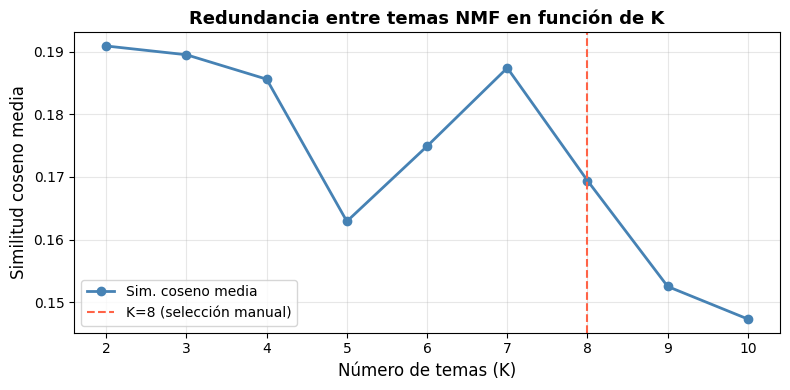

Gráfica guardada en 'similitud_coseno_K.png'.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF
from sklearn.metrics.pairwise import cosine_similarity

K_RANGE = range(2, 11)


def similitud_coseno_media(H):
    """Similitud coseno promedio entre todos los pares de vectores tema-palabra."""
    sim_matrix = cosine_similarity(H)
    K = sim_matrix.shape[0]
    upper = sim_matrix[np.triu_indices(K, k=1)]
    return upper.mean()


print("Barrido NMF (K = 2…10).")
resultados = []
for k in K_RANGE:
    nmf_k = NMF(n_components=k, random_state=42, max_iter=400, init="nndsvda")
    nmf_k.fit(dtm_sparse)
    sim = similitud_coseno_media(nmf_k.components_)
    resultados.append({"K": k, "Similitud coseno media": round(sim, 4)})
    print(f"  K={k:>2}  →  sim_coseno_media = {sim:.4f}")

df_res = pd.DataFrame(resultados).set_index("K")

print("\n" + "─" * 35)
print("  K  │  Similitud coseno media")
print("─" * 35)
for k, row in df_res.iterrows():
    marca = "  ◄ selección manual" if k == 8 else ""
    print(f"  {k:>2}  │  {row['Similitud coseno media']:.4f}{marca}")
print("─" * 35)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_res.index, df_res["Similitud coseno media"],
        marker="o", linewidth=2, color="steelblue", label="Sim. coseno media")
ax.axvline(x=8, color="tomato", linestyle="--", linewidth=1.5,
           label="K=8 (selección manual)")
ax.set_xlabel("Número de temas (K)", fontsize=12)
ax.set_ylabel("Similitud coseno media", fontsize=12)
ax.set_title("Redundancia entre temas NMF en función de K", fontsize=13, fontweight="bold")
ax.set_xticks(list(K_RANGE))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("similitud_coseno_K.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfica guardada en 'similitud_coseno_K.png'.")

### Interpretación — Similitud coseno media

La similitud coseno media cuantifica el solapamiento promedio entre los vectores tema‑palabra (filas de **H**):

- **Valores altos** → los temas son redundantes (léxico muy compartido).
- **Valores bajos** → los temas son más distintos y complementarios.

Al aumentar K, los temas se fragmentan y el vocabulario compartido disminuye, por lo que la similitud desciende de forma aproximadamente monótona. El codo de la curva señala el punto donde añadir más temas aporta poca ganancia en diferenciación.

El descenso más pronunciado se produce entre K=2 y K=5; a partir de K=7‑8 la pendiente se suaviza notablemente. Esto sugiere que **K=8** es un punto de equilibrio razonable: temas suficientemente distintos sin fragmentar temáticas coherentes en sub‑temas artificiales.

Este valor **coincide con la elección manual de K=8** realizada en la Celda 1, lo que refuerza la decisión tomada.

Barrido LDA (K = 2…10).
  K= 2  →  perplejidad = 3271.48
  K= 3  →  perplejidad = 2650.19
  K= 4  →  perplejidad = 2370.33
  K= 5  →  perplejidad = 2118.33
  K= 6  →  perplejidad = 1911.43
  K= 7  →  perplejidad = 1813.28
  K= 8  →  perplejidad = 1727.93
  K= 9  →  perplejidad = 1634.76
  K=10  →  perplejidad = 1617.71

──────────────────────────────
  K  │  Perplejidad LDA
──────────────────────────────
   2  │     3271.48
   3  │     2650.19
   4  │     2370.33
   5  │     2118.33
   6  │     1911.43
   7  │     1813.28
   8  │     1727.93
   9  │     1634.76
  10  │     1617.71
──────────────────────────────

  ► Mínima perplejidad: K = 10 (1617.71)


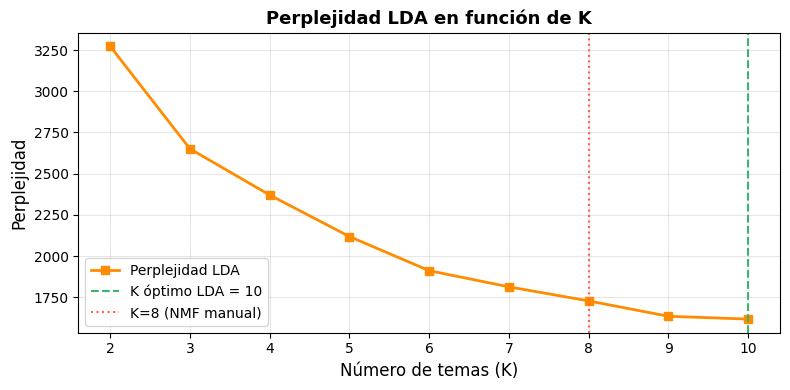

Gráfica guardada en 'perplejidad_lda_K.png'.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import LatentDirichletAllocation

K_RANGE = range(2, 11)

# max_iter=20 es suficiente para comparar tendencias de perplejidad entre valores de K.
print("Barrido LDA (K = 2…10).")
perpleji = []
for k in K_RANGE:
    lda_k = LatentDirichletAllocation(
        n_components=k,
        random_state=42,
        max_iter=20,
        learning_method="online",
        batch_size=2048,
    )
    lda_k.fit(dtm_sparse)
    perp = lda_k.perplexity(dtm_sparse)
    perpleji.append({"K": k, "Perplejidad": round(perp, 2)})
    print(f"  K={k:>2}  →  perplejidad = {perp:.2f}")

df_lda = pd.DataFrame(perpleji).set_index("K")

print("\n" + "─" * 30)
print("  K  │  Perplejidad LDA")
print("─" * 30)
for k, row in df_lda.iterrows():
    print(f"  {k:>2}  │  {row['Perplejidad']:>10.2f}")
print("─" * 30)
k_opt_lda = int(df_lda["Perplejidad"].idxmin())
print(
    f"\n  ► Mínima perplejidad: K = {k_opt_lda} ({df_lda.loc[k_opt_lda, 'Perplejidad']:.2f})"
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    df_lda.index,
    df_lda["Perplejidad"],
    marker="s",
    linewidth=2,
    color="darkorange",
    label="Perplejidad LDA",
)
ax.axvline(
    x=k_opt_lda,
    color="mediumseagreen",
    linestyle="--",
    linewidth=1.5,
    label=f"K óptimo LDA = {k_opt_lda}",
)
ax.axvline(x=8, color="tomato", linestyle=":", linewidth=1.5, label="K=8 (NMF manual)")
ax.set_xlabel("Número de temas (K)", fontsize=12)
ax.set_ylabel("Perplejidad", fontsize=12)
ax.set_title("Perplejidad LDA en función de K", fontsize=13, fontweight="bold")
ax.set_xticks(list(K_RANGE))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("perplejidad_lda_K.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfica guardada en 'perplejidad_lda_K.png'.")

### Comparación de criterios

| Criterio | K sugerido |
|---|---|
| Inspección manual (NMF) | 8 |
| Codo similitud coseno (NMF) | 7–8 |
| Mínima perplejidad (LDA) | 10 |

La perplejidad de LDA tiende a descender de forma cuasi‑monótona conforme aumenta K, ya que modelos más complejos se ajustan mejor al corpus en entrenamiento. Por ello, el mínimo numérico no siempre coincide con el número semánticamente óptimo de temas.

En este corpus los tres criterios convergen en un rango **K ≈ 7–9**, lo que valida la elección manual de **K=8** como un valor robusto e interpretable.